In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import random
from tqdm import tqdm
import time
import datetime

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [ ]:
class VegetableDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Initialize the dataset with root directory and optional transform
        
        Args:
            root_dir: Directory with all the vegetable class folders
            transform: Optional transform to be applied on a sample
        """
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        self.samples = []
        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            class_idx = self.class_to_idx[class_name]
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(class_path, img_name), class_idx))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, class_idx = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, class_idx


def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])


class VegetableClassifier:
    def __init__(self, num_classes=15, model_name="resnet50", pretrained=True):
        """
        Initialize the vegetable classifier
        
        Args:
            num_classes: Number of vegetable classes
            model_name: Name of the base model architecture
            pretrained: Whether to use pretrained weights
        """
        self.num_classes = num_classes
        self.model_name = model_name
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        
        # Create model
        self.model = self._create_model(model_name, pretrained, num_classes)
        self.model = self.model.to(self.device)
        
        # Define class names
        self.class_names = [
            'bean', 'bitter_gourd', 'bottle_gourd', 'brinjal', 'broccoli', 
            'cabbage', 'capsicum', 'carrot', 'cauliflower', 'cucumber', 
            'papaya', 'potato', 'pumpkin', 'radish', 'tomato'
        ]
    
    def _create_model(self, model_name, pretrained, num_classes):
        if model_name == "resnet50":
            model = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif model_name == "efficientnet_b0":
            model = models.efficientnet_b0(weights='IMAGENET1K_V1' if pretrained else None)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        elif model_name == "mobilenet_v2":
            model = models.mobilenet_v2(weights='IMAGENET1K_V1' if pretrained else None)
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        else:
            raise ValueError(f"Model {model_name} not supported")
        
        return model
    
    def train(self, train_dir, val_dir, batch_size=32, num_epochs=30, learning_rate=0.001):
        """
        Train the vegetable classification model with detailed progress updates
        
        Args:
            train_dir: Directory containing training data
            val_dir: Directory containing validation data
            batch_size: Batch size for training
            num_epochs: Number of training epochs
            learning_rate: Initial learning rate
        """
        train_dataset = VegetableDataset(train_dir, transform=get_transforms(train=True))
        val_dataset = VegetableDataset(val_dir, transform=get_transforms(train=False))
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
        
        class_counts = {}
        for _, label in train_dataset.samples:
            class_name = train_dataset.classes[label]
            class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        print(f"\n{'='*60}")
        print(f"DATASET INFORMATION:")
        print(f"{'='*60}")
        print(f"Total training images: {len(train_dataset)}")
        print(f"Total validation images: {len(val_dataset)}")
        print(f"Image dimensions: 224x224")
        print(f"Number of classes: {len(train_dataset.classes)}")
        print(f"Classes found: {train_dataset.classes}")
        print(f"\nClass distribution in training set:")
        for class_name, count in class_counts.items():
            print(f"  {class_name}: {count} images ({count/len(train_dataset)*100:.1f}%)")
        
        self.class_names = train_dataset.classes
        
        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        
        print(f"\n{'='*60}")
        print(f"MODEL INFORMATION:")
        print(f"{'='*60}")
        print(f"Architecture: {self.model_name}")
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
        print(f"Device: {self.device}")
        
        print(f"\n{'='*60}")
        print(f"TRAINING SETTINGS:")
        print(f"{'='*60}")
        print(f"Batch size: {batch_size}")
        print(f"Initial learning rate: {learning_rate}")
        print(f"Number of epochs: {num_epochs}")
        print(f"Optimizer: Adam")
        print(f"Learning rate scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
        print(f"Image augmentations: RandomResizedCrop, RandomHorizontalFlip, RandomRotation, ColorJitter")
        print(f"{'='*60}\n")
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        
        best_val_acc = 0.0
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []
        no_improve_epochs = 0
        early_stop_patience = 15
        
        print(f"Starting training...")
        print(f"{'='*100}")
        print(f"{'Epoch':^10}|{'Progress':^20}|{'Train Loss':^15}|{'Train Acc':^15}|{'Val Loss':^15}|{'Val Acc':^15}|{'Time':^10}")
        print(f"{'-'*100}")
        
        best_class_accuracies = {}
        
        for epoch in range(num_epochs):
            epoch_start_time = time.time()
            
            self.model.train()
            running_loss = 0.0
            correct = 0
            total = 0
            
            train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", 
                              leave=False, ncols=100)
            
            for inputs, labels in train_pbar:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                
                optimizer.zero_grad()
                
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                train_pbar.set_postfix({'loss': loss.item(), 'acc': correct/total})
            
            epoch_train_loss = running_loss / len(train_loader.dataset)
            epoch_train_acc = correct / total
            train_losses.append(epoch_train_loss)
            train_accs.append(epoch_train_acc)
            
            self.model.eval()
            running_loss = 0.0
            correct = 0
            total = 0
            
            class_correct = [0] * len(self.class_names)
            class_total = [0] * len(self.class_names)
            
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", 
                           leave=False, ncols=100)
            
            with torch.no_grad():
                for inputs, labels in val_pbar:
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    outputs = self.model(inputs)
                    loss = criterion(outputs, labels)
                    
                    running_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
                    
                    for i in range(labels.size(0)):
                        label = labels[i]
                        class_correct[label] += (predicted[i] == label).item()
                        class_total[label] += 1
                    
                    val_pbar.set_postfix({'loss': loss.item(), 'acc': correct/total})
            
            epoch_val_loss = running_loss / len(val_loader.dataset)
            epoch_val_acc = correct / total
            val_losses.append(epoch_val_loss)
            val_accs.append(epoch_val_acc)
            
            scheduler.step(epoch_val_loss)
            
            class_accuracies = {}
            for i in range(len(self.class_names)):
                if class_total[i] > 0:
                    class_accuracies[self.class_names[i]] = class_correct[i] / class_total[i]
            
            is_best = False
            if epoch_val_acc > best_val_acc:
                is_best = True
                best_val_acc = epoch_val_acc
                best_class_accuracies = class_accuracies.copy()
                torch.save(self.model.state_dict(), 'best_vegetable_model.pth')
                no_improve_epochs = 0
            else:
                no_improve_epochs += 1
            
            if no_improve_epochs >= early_stop_patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs with no improvement")
                break
            
            epoch_time = time.time() - epoch_start_time
            progress = f"{epoch+1}/{num_epochs}"
            print(f"{epoch+1:^10}|{progress:^20}|{epoch_train_loss:^15.4f}|{epoch_train_acc:^15.4f}|"
                  f"{epoch_val_loss:^15.4f}|{epoch_val_acc:^15.4f}|{epoch_time:^10.1f}s" + 
                  (" *" if is_best else ""))
            
            if (epoch + 1) % 5 == 0 or epoch == 0 or is_best:
                print(f"\nPer-class validation accuracy:")
                for class_name, accuracy in class_accuracies.items():
                    print(f"  {class_name}: {accuracy:.4f}")
                print()
        
        print(f"{'='*100}")
        
        print(f"\n{'='*60}")
        print(f"TRAINING COMPLETE")
        print(f"{'='*60}")
        print(f"Best validation accuracy: {best_val_acc:.4f}")
        print(f"Best per-class accuracies:")
        for class_name, accuracy in best_class_accuracies.items():
            print(f"  {class_name}: {accuracy:.4f}")
        
        self.model.load_state_dict(torch.load('best_vegetable_model.pth'))
        print(f"\nLoaded best model from epoch with validation accuracy: {best_val_acc:.4f}")
        
        self._plot_training_history(train_losses, val_losses, 'Loss')
        self._plot_training_history(train_accs, val_accs, 'Accuracy')
        print(f"Training plots saved to 'loss_history.png' and 'accuracy_history.png'")
        
        return {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'best_val_acc': best_val_acc,
            'best_class_accuracies': best_class_accuracies
        }
    
    def _plot_training_history(self, train_metric, val_metric, metric_name):
        """Plot training history for a specific metric with enhanced visualization"""
        plt.figure(figsize=(12, 7))
        epochs = range(1, len(train_metric) + 1)
        
        plt.plot(epochs, train_metric, 'b-o', label=f'Training {metric_name}', markersize=4, alpha=0.7)
        plt.plot(epochs, val_metric, 'r-^', label=f'Validation {metric_name}', markersize=4, alpha=0.7)
        
        if metric_name.lower() == 'loss':
            best_epoch = val_metric.index(min(val_metric)) + 1
            best_value = min(val_metric)
        else:
            best_epoch = val_metric.index(max(val_metric)) + 1
            best_value = max(val_metric)
        
        plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)
        plt.scatter(best_epoch, best_value, s=150, c='green', marker='*', 
                    label=f'Best {metric_name}: {best_value:.4f} (Epoch {best_epoch})')
        
        try:
            from scipy.signal import savgol_filter
            if len(val_metric) > 7:  # Need enough points for smoothing
                window_size = min(7, len(val_metric) - 2)
                if window_size % 2 == 0:  # Window size must be odd
                    window_size += 1
                yhat = savgol_filter(val_metric, window_size, 2)
                plt.plot(epochs, yhat, 'g--', linewidth=1, alpha=0.8, label='Trend')
        except ImportError:
            pass  
        
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel(metric_name, fontsize=12)
        plt.title(f'Training and Validation {metric_name} Over Time', fontsize=14)
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.7)
        
        plt.xticks(epochs[::max(1, len(epochs)//10)])  # Show reasonable number of x-ticks
        
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
        plt.figtext(0.02, 0.02, f"Model: {self.model_name} | Generated: {timestamp}", 
                   fontsize=8, color='gray')
        
        plt.tight_layout()
        plt.savefig(f'{metric_name.lower()}_history.png', dpi=300)
        
        return plt
    
    def evaluate(self, test_dir, batch_size=32):
        """
        Evaluate the model on test data with detailed metrics
        
        Args:
            test_dir: Directory containing test data
            batch_size: Batch size for evaluation
        """
        print(f"\n{'='*60}")
        print(f"EVALUATING MODEL ON TEST DATA")
        print(f"{'='*60}")
        
        test_dataset = VegetableDataset(test_dir, transform=get_transforms(train=False))
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
        
        print(f"Test dataset: {len(test_dataset)} images")
        print(f"Test batch size: {batch_size}")
        
        self.model.eval()
        all_preds = []
        all_labels = []
        correct = 0
        total = 0
        
        class_correct = {cls: 0 for cls in self.class_names}
        class_total = {cls: 0 for cls in self.class_names}
        
        top3_correct = 0
        
        # Track inference time
        inference_times = []
        
        print(f"\nRunning evaluation...")
        start_time = time.time()
        
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader, desc="Evaluating"):
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                
                batch_start = time.time()
                outputs = self.model(inputs)
                batch_end = time.time()
                
                inference_times.append((batch_end - batch_start) / inputs.size(0))
                
                _, predicted = torch.max(outputs, 1)
                
                _, top3_preds = torch.topk(outputs, 3, dim=1)
                for i, label in enumerate(labels):
                    if label in top3_preds[i]:
                        top3_correct += 1
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                for i, label in enumerate(labels):
                    label_name = self.class_names[label.item()]
                    class_total[label_name] += 1
                    if predicted[i] == label:
                        class_correct[label_name] += 1
        
        accuracy = correct / total
        top3_accuracy = top3_correct / total
        avg_inference_time = sum(inference_times) / len(inference_times)
        total_eval_time = time.time() - start_time
        
        # Print summary
        print(f"\n{'='*60}")
        print(f"EVALUATION RESULTS")
        print(f"{'='*60}")
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Top-3 Accuracy: {top3_accuracy:.4f}")
        print(f"Average inference time per image: {avg_inference_time*1000:.2f} ms")
        print(f"Total evaluation time: {total_eval_time:.2f} seconds")
        
        # Per-class accuracy
        print(f"\nPer-class accuracy:")
        for cls in sorted(self.class_names):
            if class_total[cls] > 0:
                print(f"  {cls}: {class_correct[cls]/class_total[cls]:.4f} ({class_correct[cls]}/{class_total[cls]})")
        
        # Calculate confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        
        # Calculate classification report
        report = classification_report(
            all_labels, all_preds, 
            target_names=self.class_names, 
            output_dict=True
        )
        
        # Plot confusion matrix
        self._plot_confusion_matrix(cm)
        print(f"\nConfusion matrix saved to 'confusion_matrix.png'")
        
        # Display classification report
        report_df = pd.DataFrame(report).transpose()
        print(f"\nDetailed classification report:")
        print(report_df)
        
        # Save the report
        report_df.to_csv('classification_report.csv')
        print(f"Classification report saved to 'classification_report.csv'")
        
        # Find most confused pairs
        print(f"\nMost confused class pairs:")
        n_confused_pairs = 5
        confused_pairs = []
        
        for i in range(len(self.class_names)):
            for j in range(len(self.class_names)):
                if i != j:
                    confused_pairs.append((self.class_names[i], self.class_names[j], cm[i, j]))
        
        confused_pairs.sort(key=lambda x: x[2], reverse=True)
        for true_class, pred_class, count in confused_pairs[:n_confused_pairs]:
            print(f"  True: {true_class}, Predicted: {pred_class}, Count: {count}")
        
        return accuracy, cm, report
    
    def _plot_confusion_matrix(self, cm):
        """Plot confusion matrix"""
        plt.figure(figsize=(15, 15))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        
        # Add class labels
        tick_marks = np.arange(len(self.class_names))
        plt.xticks(tick_marks, self.class_names, rotation=90)
        plt.yticks(tick_marks, self.class_names)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], 'd'),
                         horizontalalignment="center",
                         color="white" if cm[i, j] > thresh else "black")
        
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png')
    
    def save_model(self, path='vegetable_classifier.pth'):
        """Save model weights to disk"""
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")
    
    def load_model(self, path='vegetable_classifier.pth'):
        """Load model weights from disk"""
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        self.model.eval()
        print(f"Model loaded from {path}")
    
    def predict(self, image_path):
        """
        Predict the class of a vegetable from an image file
        
        Args:
            image_path: Path to the image file
            
        Returns:
            Predicted class, probability, and top 3 predictions
        """
        # Load and preprocess the image
        image = Image.open(image_path).convert('RGB')
        transform = get_transforms(train=False)
        image_tensor = transform(image).unsqueeze(0).to(self.device)
        
        # Make prediction
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(image_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)[0]
            
            # Get the predicted class and probability
            predicted_class_idx = torch.argmax(probabilities).item()
            probability = probabilities[predicted_class_idx].item()
            
            # Get top 3 predictions
            top3_values, top3_indices = torch.topk(probabilities, 3)
            top3_predictions = [
                (self.class_names[idx.item()], val.item())
                for idx, val in zip(top3_indices, top3_values)
            ]
        
        return self.class_names[predicted_class_idx], probability, top3_predictions


In [4]:
# Example of using the model in a Jupyter notebook
def run_vegetable_classifier(data_dir='dataset', model_name='resnet50', batch_size=32, 
                           num_epochs=30, learning_rate=0.001, eval_only=False,
                           model_path=None):
    """
    Run the vegetable classifier with the specified parameters.
    This function wraps the main functionality for easy use in a Jupyter notebook.
    """
    # Print system info
    print(f"\n{'='*60}")
    print(f"SYSTEM INFORMATION")
    print(f"{'='*60}")
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"{'='*60}")
    
    # Set paths
    train_dir = os.path.join(data_dir, 'train')
    val_dir = os.path.join(data_dir, 'validation')
    test_dir = os.path.join(data_dir, 'test')
    
    # Check if directories exist
    for directory in [train_dir, val_dir, test_dir]:
        if not os.path.exists(directory):
            print(f"Warning: Directory {directory} does not exist!")
    
    # Create the classifier
    classifier = VegetableClassifier(num_classes=15, model_name=model_name)
    
    # Load model if provided
    if model_path:
        try:
            classifier.load_model(model_path)
            print(f"Model loaded from {model_path}")
        except Exception as e:
            print(f"Error loading model: {str(e)}")
            if eval_only:
                print("Exiting as evaluation only mode was selected.")
                return None
    
    # Training phase
    if not eval_only:
        print(f"\n{'='*60}")
        print(f"STARTING TRAINING")
        print(f"{'='*60}")
        
        # Create output directory for results
        os.makedirs('results', exist_ok=True)
        
        # Train the model
        history = classifier.train(
            train_dir=train_dir,
            val_dir=val_dir,
            batch_size=batch_size,
            num_epochs=num_epochs,
            learning_rate=learning_rate
        )
        
        # Save the model
        model_save_path = f'results/vegetable_classifier_{model_name}_{datetime.datetime.now().strftime("%Y%m%d_%H%M")}.pth'
        classifier.save_model(model_save_path)
    
    # Evaluation phase
    if os.path.exists(test_dir):
        print(f"\n{'='*60}")
        print(f"STARTING EVALUATION")
        print(f"{'='*60}")
        
        # Evaluate on test set
        accuracy, confusion_mat, report = classifier.evaluate(test_dir, batch_size=batch_size)
        
        # Save evaluation results
        os.makedirs('results', exist_ok=True)
        results_summary = {
            'model': model_name,
            'accuracy': accuracy,
            'test_set': test_dir,
            'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        
        with open('results/evaluation_summary.txt', 'w') as f:
            for key, value in results_summary.items():
                f.write(f"{key}: {value}\n")
        
        print(f"\nEvaluation complete. Results saved to 'results' directory.")
    
    # Example of single image prediction
    print(f"\n{'='*60}")
    print(f"EXAMPLE PREDICTION")
    print(f"{'='*60}")
    
    # Try to find a sample image from the test directory
    sample_image_path = None
    if os.path.exists(test_dir):
        class_dirs = [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]
        if class_dirs:
            sample_class = class_dirs[0]
            sample_class_dir = os.path.join(test_dir, sample_class)
            image_files = [f for f in os.listdir(sample_class_dir) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if image_files:
                sample_image_path = os.path.join(sample_class_dir, image_files[0])
    
    if sample_image_path:
        print(f"Making prediction on sample image: {sample_image_path}")
        predicted_class, confidence, top_3 = classifier.predict(sample_image_path)
        print(f"True class: {os.path.basename(os.path.dirname(sample_image_path))}")
        print(f"Predicted: {predicted_class} with {confidence:.2%} confidence")
        print("Top 3 predictions:")
        for veg, conf in top_3:
            print(f"  {veg}: {conf:.2%}")
    else:
        print("No sample image found for prediction example.")
    
    print(f"\n{'='*60}")
    print(f"TRAINING AND EVALUATION COMPLETE")
    print(f"{'='*60}")
    
    return classifier

# Add utility functions for visualizing model predictions
def display_prediction_results(image_path, classifier):
    """Display an image with its predictions"""
    image = Image.open(image_path).convert('RGB')
    predicted_class, confidence, top_3 = classifier.predict(image_path)
    
    # Display the image
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis('off')
    
    # Add prediction info as title
    true_class = os.path.basename(os.path.dirname(image_path))
    plt.title(f"True: {true_class} | Predicted: {predicted_class} ({confidence:.2%})", 
              fontsize=14)
    
    # Add top 3 predictions as text
    prediction_text = "\n".join([f"{veg}: {conf:.2%}" for veg, conf in top_3])
    plt.figtext(0.92, 0.5, f"Top 3 Predictions:\n{prediction_text}", 
                fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return predicted_class == true_class

def visualize_batch_predictions(test_dir, classifier, num_samples=10):
    """Visualize model predictions on a batch of random test images"""
    # Collect all test images
    all_images = []
    for class_name in os.listdir(test_dir):
        class_dir = os.path.join(test_dir, class_name)
        if os.path.isdir(class_dir):
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_images.append(os.path.join(class_dir, img_file))
    
    # Select random samples
    if len(all_images) > num_samples:
        random_samples = random.sample(all_images, num_samples)
    else:
        random_samples = all_images
    
    # Create grid for visualization
    rows = (num_samples + 2) // 3  # Calculate needed rows
    fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
    axes = axes.flatten()
    
    correct_count = 0
    
    for i, img_path in enumerate(random_samples):
        if i < len(axes):
            # Load image
            img = Image.open(img_path).convert('RGB')
            
            # Get prediction
            true_class = os.path.basename(os.path.dirname(img_path))
            predicted_class, confidence, _ = classifier.predict(img_path)
            
            # Update correct count
            if predicted_class == true_class:
                correct_count += 1
                result_color = 'green'
            else:
                result_color = 'red'
            
            # Display image
            axes[i].imshow(img)
            axes[i].set_title(f"True: {true_class}\nPred: {predicted_class} ({confidence:.1%})", 
                             color=result_color)
            axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"Model Predictions (Accuracy: {correct_count}/{len(random_samples)} = {correct_count/len(random_samples):.1%})", 
                fontsize=16, y=1.02)
    plt.show()
    
    return correct_count / len(random_samples)

def show_class_examples(data_dir, class_name, num_examples=8):
    """Show example images from a specific class"""
    # Find class directory
    class_dir = None
    for split in ['train', 'validation', 'test']:
        potential_dir = os.path.join(data_dir, split, class_name)
        if os.path.exists(potential_dir):
            class_dir = potential_dir
            break
    
    if not class_dir:
        print(f"Class '{class_name}' not found in dataset.")
        return
    
    # Get image files
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(image_files) == 0:
        print(f"No images found for class '{class_name}'.")
        return
    
    # Select random samples
    if len(image_files) > num_examples:
        selected_files = random.sample(image_files, num_examples)
    else:
        selected_files = image_files
    
    # Create grid for visualization
    cols = 4
    rows = (len(selected_files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 3))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, img_file in enumerate(selected_files):
        img_path = os.path.join(class_dir, img_file)
        img = Image.open(img_path).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(f"{img_file}", fontsize=8)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(len(selected_files), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f"Examples of class: {class_name}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [ ]:
# Example usage in a Jupyter notebook:
# Train a new model
classifier = run_vegetable_classifier(
    data_dir='dataset',
    model_name='resnet50',
    batch_size=32,
    num_epochs=5
)


SYSTEM INFORMATION
PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
GPU: NVIDIA GeForce GTX 1650 Ti
GPU memory: 3.90 GB
Using device: cuda

STARTING TRAINING

DATASET INFORMATION:
Total training images: 15000
Total validation images: 3000
Image dimensions: 224x224
Number of classes: 15
Classes found: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']

Class distribution in training set:
  Bean: 1000 images (6.7%)
  Bitter_Gourd: 1000 images (6.7%)
  Bottle_Gourd: 1000 images (6.7%)
  Brinjal: 1000 images (6.7%)
  Broccoli: 1000 images (6.7%)
  Cabbage: 1000 images (6.7%)
  Capsicum: 1000 images (6.7%)
  Carrot: 1000 images (6.7%)
  Cauliflower: 1000 images (6.7%)
  Cucumber: 1000 images (6.7%)
  Papaya: 1000 images (6.7%)
  Potato: 1000 images (6.7%)
  Pumpkin: 1000 images (6.7%)
  Radish: 1000 images (6.7%)
  Tomato: 1000 images (6.7%)

MODEL

    1     |        1/5         |    0.5761     |    0.8277     |    0.1940     |    0.9423     |  297.6   s *

Per-class validation accuracy:
  Bean: 0.9650
  Bitter_Gourd: 0.9600
  Bottle_Gourd: 0.9650
  Brinjal: 0.6350
  Broccoli: 0.9250
  Cabbage: 1.0000
  Capsicum: 0.9700
  Carrot: 0.9950
  Cauliflower: 0.9800
  Cucumber: 0.8900
  Papaya: 0.9750
  Potato: 1.0000
  Pumpkin: 0.9800
  Radish: 0.9900
  Tomato: 0.9050



    2     |        2/5         |    0.2221     |    0.9331     |    0.1269     |    0.9753     |  320.6   s *

Per-class validation accuracy:
  Bean: 1.0000
  Bitter_Gourd: 1.0000
  Bottle_Gourd: 0.9900
  Brinjal: 0.9500
  Broccoli: 0.9800
  Cabbage: 1.0000
  Capsicum: 0.9900
  Carrot: 1.0000
  Cauliflower: 0.9900
  Cucumber: 0.7850
  Papaya: 0.9950
  Potato: 0.9900
  Pumpkin: 0.9750
  Radish: 0.9950
  Tomato: 0.9900



Epoch 3/5 [Train]:  35%|██████▎           | 166/469 [01:37<03:44,  1.35it/s, loss=0.0136, acc=0.954]

Using device: cuda
Model loaded from best_vegetable_model.pth
Class 'tomato' not found in dataset.


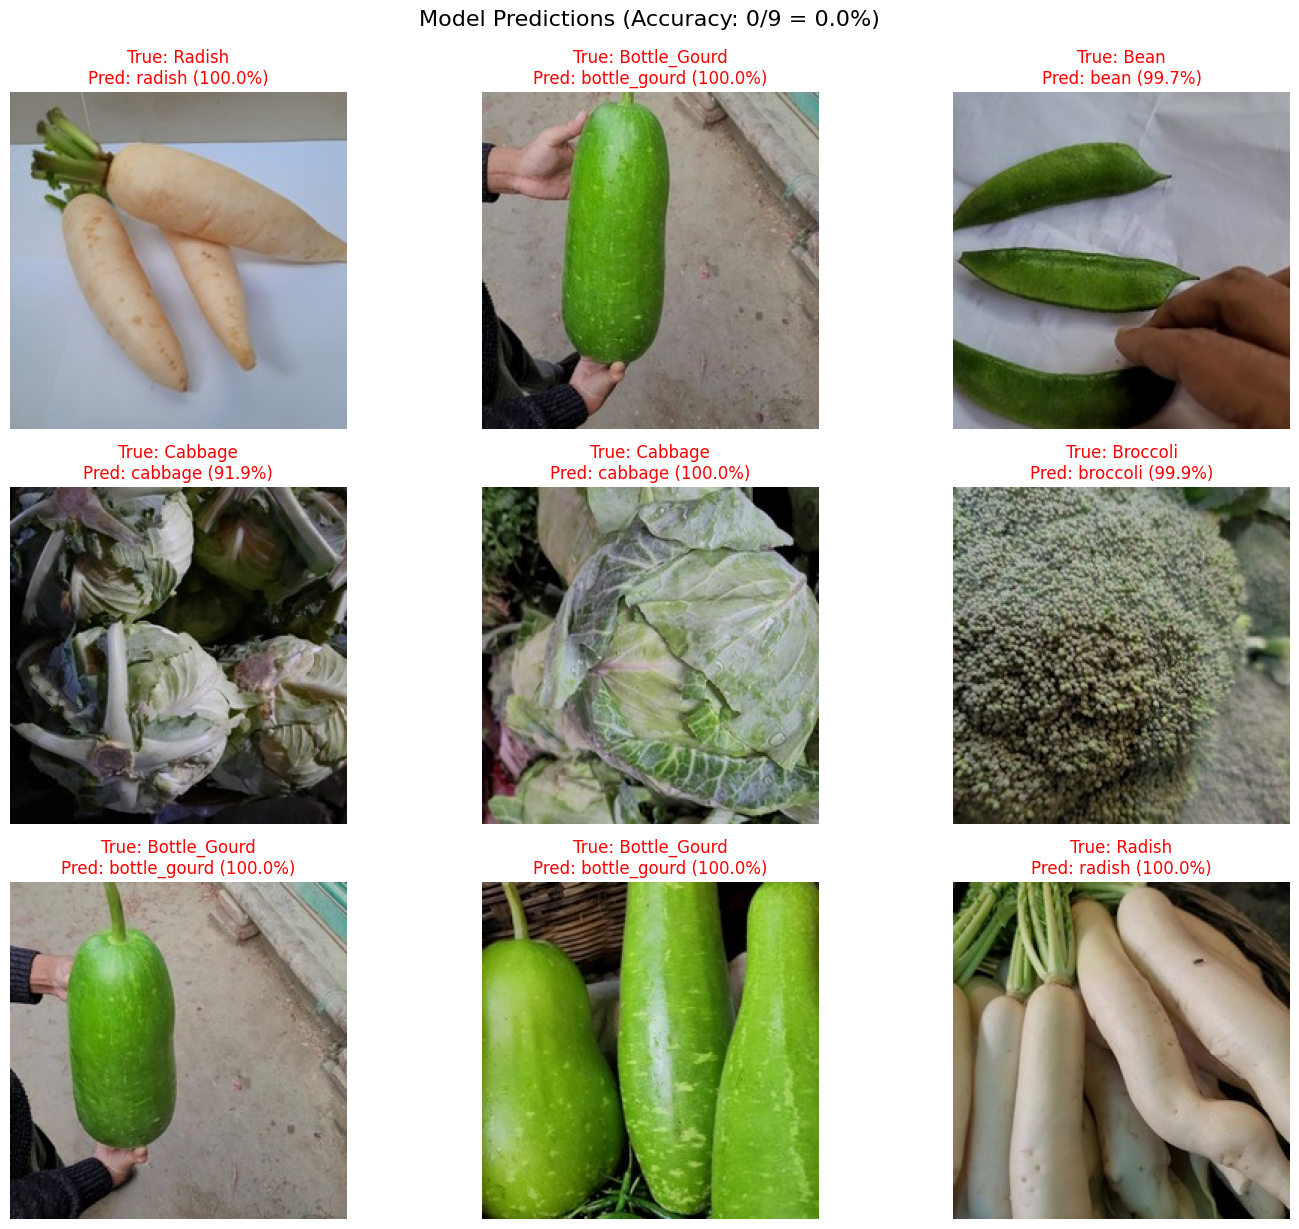

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/test/carrot/some_image.jpg'

In [5]:
# Or load a pre-trained model
classifier = VegetableClassifier(num_classes=15, model_name='resnet50')
classifier.load_model('best_vegetable_model.pth')

# Visualize some examples
show_class_examples('dataset', 'tomato')

# Visualize predictions
visualize_batch_predictions('dataset/test', classifier, num_samples=9)

# Make a single prediction
image_path = 'dataset/test/carrot/some_image.jpg'
display_prediction_results(image_path, classifier)